# Декомпозиция временного ряда

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose # Декомпозиция временных рядов
from statsmodels.tsa.api import SimpleExpSmoothing # Экспотенциальное сглаживание
from statsmodels.tsa.stattools import adfuller # Проверка на стационарность/нестационарность данных
from statsmodels.graphics.tsaplots import plot_acf # Автокорреляция
from statsmodels.tsa.ar_model import AutoReg # Авторегрессионная модель (АR)

В этом датасете представлены данные о количестве авиапассажиров в 1949-1960 годах. Рассмотрим некоторый временной ряд df из данного датасета.

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<Axes: xlabel='Month'>

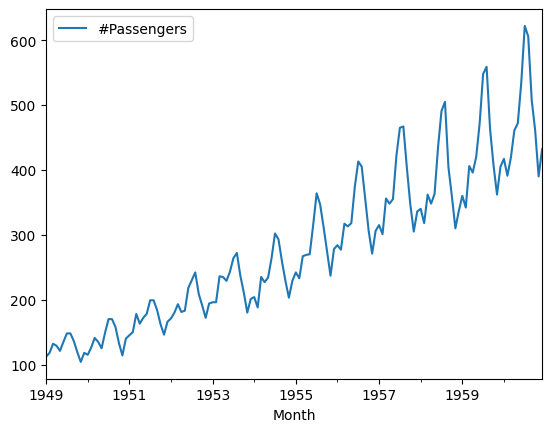

In [13]:
air_df = pd.read_csv('Data/AirPassengers.csv', index_col='Month', parse_dates=['Month'])
display(air_df.head(5))
air_df.plot()

Декомпозиция выполняется методом seasonal_decompose(), который принимает на вход временной ряд с одним признаком. Индексом ряда должна быть __дата__ или __время__. Именно поэтому, считывая датасет, мы указываем индексом столбец month и приводим его к формату даты. Также, если вы знаете, что в вашем временном ряду присутствует период, его вы также можете передать в качестве параметра в seasonal_decompose()

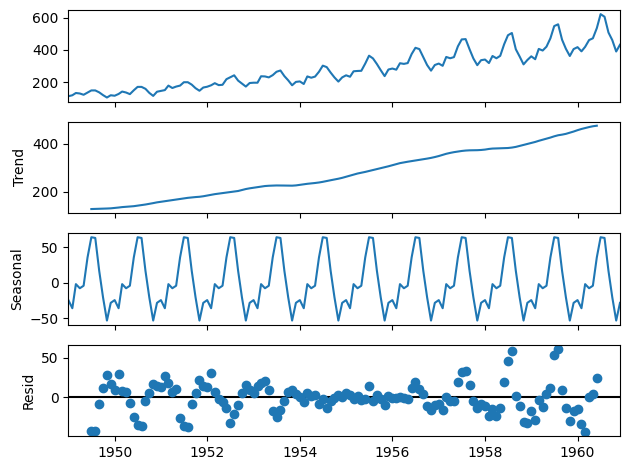

In [11]:
# производим декомпозицию временного ряда 
decomposition = seasonal_decompose(air_df)
fig = decomposition.plot()
plt.show()

Как можно увидеть, по исходному ряду был получен тренд, выявлена некоторая сезонность и шум.

# Экспоненциальное сглаживание

In [18]:
def exp_smth(x_t, a, s_t_1):
    return a * x_t + (1 - a) * s_t_1 # Если брать сырую формулу

data = np.array([15, 20, 25, 30, 25, 27])
a = 0.7
s = np.zeros(6)
s[0] = data[0]

for i in range(1, len(data)):
    s[i] = exp_smth(data[i], a, s[i-1])

print(s)

[15.      18.5     23.05    27.915   25.8745  26.66235]


In [21]:
# Передаём данные (временной ряд) в модель простого экспоненциального сглаживания
ses = SimpleExpSmoothing(data)

# Задаём коэффициент сглаживания alpha (чем ближе к 1, тем больше вес у последних наблюдений)
alpha = 0.7

# Обучаем модель, устанавливая вручную значение alpha (опция optimized=False означает, что не нужно подбирать оптимальное alpha автоматически)
model = ses.fit(smoothing_level=alpha, optimized=False)

# Делаем прогноз на 1 шаг вперёд (например, предсказание следующего значения временного ряда)
forecast = model.forecast(1)

# Выводим результат прогноза
print(forecast)

[26.66235]


# Статистические тесты (проверка на стационарность/нестационарность)

Рассмотрим пример проведения теста Дики — Фуллера на данных временного ряда Daily Total Female Births. В данных содержится количественная информация о девочках, рождённых за несколько месяцев. Для проведения теста будем использовать функцию adfuller() из пакета statsmodels.

In [33]:
# Параметр header=0 означает, что первая строка содержит имена столбцов
# index_col=0 делает первую колонку (дату) индексом
# squeeze("columns") преобразует DataFrame в Series, если остался один столбец
female_df = pd.read_csv(
    'Data/daily-total-female-births.csv',
    header=0,
    index_col=0
).squeeze("columns")

# Применяем тест Дики-Фуллера (Augmented Dickey-Fuller) для проверки стационарности временного ряда
# female_df.values — передаём данные в виде массива numpy
result = adfuller(female_df.values)

# Выводим ADF-статистику — она показывает, насколько сильны признаки стационарности
print(f"ADF Statistic: {result[0]}")

# Выводим p-value — основная величина для принятия решения
# Если p < 0.05, можно считать, что ряд стационарен (отвергаем нулевую гипотезу о нестационарности)
print(f"p-value: {result[1]:.7f}")

# Выводим критические значения для сравнения с ADF-статистикой (на уровне значимости 1%, 5%, 10%)
print("Critical Values:")
for key, value in result[4].items():
    print(f"\t{key}: {value:.3f}")

ADF Statistic: -4.808291253559767
p-value: 0.0000524
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571


Вывод:
* 0.0000524 < 0.05

Значит, p-value меньше 0.05, мы уверенно отвергаем нулевую гипотезу (H0).

Ряд стационарный!

Напоминание:
* p < 0.01	- Очень сильные доказательства против H0
* p < 0.05	- Умеренные доказательства против H0
* p ≥ 0.05	- Недостаточно оснований отвергнуть H0

# Автокорреляция (построение графиков)

Воспользуемся датасетом из примера сезонной декомпозиции, в котором представлены данные о количестве авиапассажиров в 1949–1960 годах.

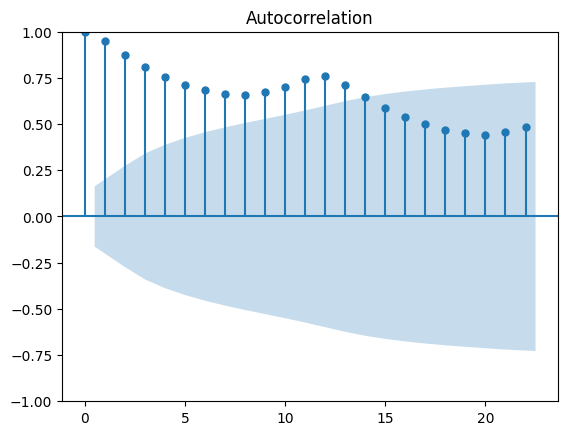

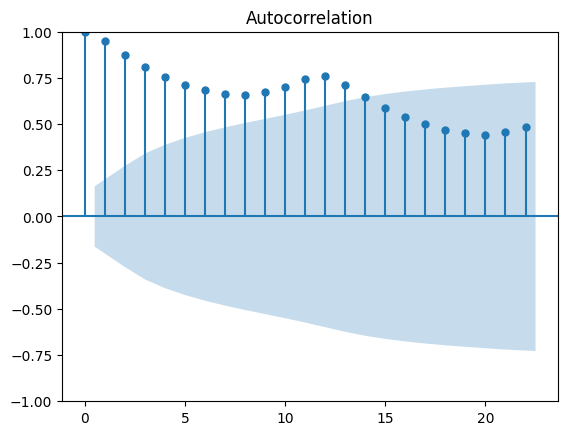

In [35]:
air_df = pd.read_csv('Data/AirPassengers.csv', index_col='Month', parse_dates=['Month'])
plot_acf(air_df)

На оси х коррелограммы расположен лаг (порядок), при котором вычисляется автокорреляция. Ось y показывает значение корреляции (от -1 до 1). Чем ближе значение корреляции к 1 или -1, тем выше зависимость, например:

* пик при лаге, равном 1, показывает сильную зависимость между значениям ряда и предыдущим значением;
* пик при лаге, равном 2, показывает сильную корреляцию между каждым значением и значением в более ранний момент на расстоянии 2 от данного.

# Моделирование авторегрессионной модели (AR, только на стационарном ряду)

Применим авторегрессионную модель к датасету по производству возобновляемой энергии в Германии. Набор данных включает общую информацию о потреблении электроэнергии в стране, а также о производстве ветровой и солнечной энергии за 2006–2017 годы.

Признаки в данных:

* Date — дата (в формате гггг-мм-дд);
* Consumption — потребление электроэнергии (ГВтч);
* Wind — производство ветровой энергии (ГВтч);
* Solar — производство солнечной энергии (ГВтч);
* Wind+Solar — сумма производства ветровой и солнечной энергии (ГВтч).

### Задача: 
Построим предсказание объёма потребления электроэнергии на три месяца (возьмём последние 100 дней).

In [3]:
opsd_df = pd.read_csv('Data/opsd_germany.csv', sep=',')
display(opsd_df.head(5))

,Date,Consumption,Wind,Solar,Wind+Solar
0,2006-01-01,1069.184,NaN,NaN,NaN
1,2006-01-02,1380.521,NaN,NaN,NaN
2,2006-01-03,1442.533,NaN,NaN,NaN
3,2006-01-04,1457.217,NaN,NaN,NaN
4,2006-01-05,1477.131,NaN,NaN,NaN


Проведём тест на __стационарность__.

In [8]:
result = adfuller(opsd_df['Consumption'].values)

if result[0] > result[4]['5%']:
    print('Ряд нестационарен')
else:
    print('Ряд стационарен')

Ряд стационарен


При использовании статистических моделей временные ряды нельзя делить на обучающую и тестовую выборки случайным образом. Так как нам важно сохранять последовательность, разделим данные на обучающую и тестовую выборки упорядоченно, то есть возьмём в качестве тестовой выборки последние 100 значений. Остальные данные будем использовать для обучения.

In [11]:
train_data = opsd_df['Consumption'][:len(opsd_df)-100]
test_data = opsd_df['Consumption'][len(opsd_df)-100:]

Инициализируем и обучим модель. Возьмём lags=8 (AR(8)) — на практике же будем определять это значение по графику частичной автокорреляции:

In [13]:
ar_model = AutoReg(train_data, lags=8).fit()
print(ar_model.summary())

                            AutoReg Model Results                             
Dep. Variable:            Consumption   No. Observations:                 4283
Model:                     AutoReg(8)   Log Likelihood              -24231.812
Method:               Conditional MLE   S.D. of innovations             70.058
Date:                Tue, 17 Jun 2025   AIC                          48483.625
Time:                        11:00:47   BIC                          48547.230
Sample:                             8   HQIC                         48506.095
                                 4283                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            121.2792     14.444      8.397      0.000      92.969     149.589
Consumption.L1     0.6393      0.013     47.751      0.000       0.613       0.666
Consumption.L2    -0.0966      0.011

Сделаем предсказание. Метод predict требует два обязательных параметра — метки начала и окончания предсказания. Метка начала предсказания будет равна количеству данных в обучающей выборке, так как нас интересует прогноз со следующего дня. Метка окончания в нашем случае будет равна len(train_data)+100, что эквивалентно len(df)-1, так как len(df) = len(train_data) + len(test_data).

In [15]:
pred = ar_model.predict(start=len(train_data), end=(len(opsd_df)-1), dynamic=False)
print(pred)

4283    1199.580761
4284    1132.051688
4285    1392.772651
4286    1425.877770
4287    1424.606502
           ...     
4378    1355.220188
4379    1359.014426
4380    1334.516355
4381    1299.851112
4382    1309.602440
Length: 100, dtype: float64
